In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
C = 20
phi = 0.04
I = 92
V_ca = 120
V_k = -84
V_l = -60
g_ca = 4.4
g_k = 8
g_l = 2
V1 = -1.2
V2 = 18
V3 = 2
V4 = 30

In [3]:
def m_inf(v):

    temp = (v - V1) / V2
    
    return 0.5 * (1 + np.tanh(temp))

def w_inf(v):

    temp = (v - V3) / V4
    
    return 0.5 * (1 + np.tanh(temp))

def tau_w(v):
    
    temp = (v - V3) / (2 * V4)
    return np.cosh(temp) ** -1

In [4]:
def fun_vt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = (- g_ca * m_inf(v) * (v - V_ca) - g_k * w * (v - V_k) - g_l * (v - V_l) + I) / C
    v_next = v +  drift * dt
#     v_next = v +  drift * dt + sigma * dw
    
    return v_next

def fun_wt(data, dt):
    
    v = data[:, 0]
    w = data[:, 1]
    drift = phi * (w_inf(v) - w) / tau_w(v)
    w_next = w +  drift * dt
    
    return w_next

In [5]:
T = 10
interval = 10000
dt = 0.1
dw = np.sqrt(dt) * np.random.normal(size=(1,))
sigma = 0.01

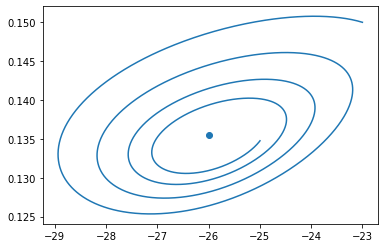

In [6]:
x0 = np.array([[-23, 0.15]])
tra_v = []
tra_w = []
tra_v.append(x0[:, 0])
tra_w.append(x0[:, 1])

data = x0
for i in range(3000):
    v = fun_vt(data, dt)
    w = fun_wt(data, dt)
    data = np.concatenate([v.reshape(-1,1), w.reshape(-1,1)], axis=1)
    tra_v.append(v)
    tra_w.append(w)
plt.plot(np.array(tra_v), np.array(tra_w))
plt.scatter(np.array(tra_v).mean(), np.array(tra_w).mean())

In [7]:
cycle = np.load('data_cycle.npy')
cycle.shape

(1000, 2)

In [8]:
plt.rcParams['font.family'] = 'Arial'

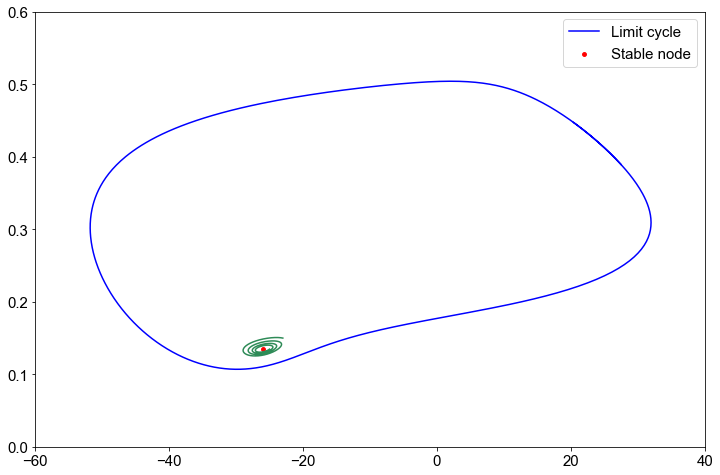

In [9]:
plt.figure(figsize=(12,8))
plt.plot(cycle[:,0], cycle[:,1], c='b', label='Limit cycle')
plt.plot(np.array(tra_v), np.array(tra_w), c='seagreen')
plt.scatter(np.array(tra_v).mean(), np.array(tra_w).mean(), c='r', s=15, label='Stable node')
plt.xlim(-60,40)
plt.ylim(0.,0.6)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
# plt.savefig('morris_limit.png', bbox_inches='tight', dpi=150)
plt.show()